# Vision Transformers in Keras

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 3

**Objective:** Combine a pretrained CNN with a Vision Transformer (ViT)
for advanced image classification: extract intermediate CNN feature
maps, reshape them as tokens, add positional embeddings, and stack
Transformer encoder blocks on top.

**Prerequisite:** run the Keras CNN training lab first, so that
`keras_cnn_classifier.keras` exists.


## 1. Import libraries and packages

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_DIR = "images_dataSAT"
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

assert os.path.exists("keras_cnn_classifier.keras"), \
    "Pretrained Keras CNN not found -- run the Keras training lab first."


I0000 00:00:1782926019.370470     954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782926019.421307     954 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782926021.143555     954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Load data

In [2]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.2, subset="training", seed=SEED,
)
val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.2, subset="validation", seed=SEED,
)

normalization = layers.Rescaling(1.0 / 255)
train_ds_ready = train_ds.map(lambda x, y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds_ready = val_ds.map(lambda x, y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)

print("Data ready.")


Found 6000 files belonging to 2 classes.


Using 4800 files for training.


Found 6000 files belonging to 2 classes.


Using 1200 files for validation.


Data ready.


### Task 1: Load and summarize a pre-trained CNN model using `load_model()` and `summary()`

In [3]:
pretrained_cnn = keras.models.load_model("keras_cnn_classifier.keras")
pretrained_cnn.summary()


Model: "satellite_cnn_keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,925 (9.25 MB)

 Trainable params: 808,641 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,617,284 (6.17 MB)

### Task 2: Identify the feature extraction layer in `feature_layer_name`

We use the output of the last `MaxPooling2D` layer -- right before the
model's `Flatten`/`Dense` classification head -- as our feature map,
since it retains full spatial structure (an `(H, W, C)` grid) that we
can later tokenize for the Transformer.


In [4]:
pool_layers = [l.name for l in pretrained_cnn.layers if isinstance(l, layers.MaxPooling2D)]
feature_layer_name = pool_layers[-1]

print("Available MaxPooling2D layers:", pool_layers)
print("Selected feature_layer_name:", feature_layer_name)


Available MaxPooling2D layers: ['max_pooling2d', 'max_pooling2d_1', 'max_pooling2d_2', 'max_pooling2d_3']
Selected feature_layer_name: max_pooling2d_3


In [5]:
# Rebuild a functional feature-extractor graph by replaying the loaded (trained)
# layers up to and including `feature_layer_name`. (A reloaded Sequential model
# doesn't retain a usable `.input` handle in Keras 3, so we reconstruct the
# functional graph explicitly, reusing the same trained layer objects/weights.)
feature_layer_idx = [l.name for l in pretrained_cnn.layers].index(feature_layer_name)

fe_inputs = keras.Input(shape=(64, 64, 3))
x = fe_inputs
for layer in pretrained_cnn.layers[: feature_layer_idx + 1]:
    x = layer(x)

feature_extractor = keras.Model(inputs=fe_inputs, outputs=x, name="cnn_feature_extractor")
feature_extractor.trainable = False

print("Feature extractor output shape:", feature_extractor.output.shape)

sample_batch, _ = next(iter(train_ds_ready))
sample_features = feature_extractor(sample_batch)
print("Feature map shape for a batch:", sample_features.shape)


Feature extractor output shape: (None, 4, 4, 128)
Feature map shape for a batch: (32, 4, 4, 128)


W0000 00:00:1782926023.218634     954 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 3. CNN feature maps -> tokens + positional embeddings

In [6]:
class PatchTokenizer(layers.Layer):
    def call(self, feature_map):
        shape = tf.shape(feature_map)
        batch, h, w, c = shape[0], shape[1], shape[2], shape[3]
        return tf.reshape(feature_map, (batch, h * w, c))


class PositionalEmbedding(layers.Layer):
    def __init__(self, num_tokens, dim, **kwargs):
        super().__init__(**kwargs)
        self.num_tokens = num_tokens
        self.dim = dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name="pos_embedding", shape=(1, self.num_tokens, self.dim), initializer="random_normal", trainable=True,
        )
        super().build(input_shape)

    def get_config(self):
        config = super().get_config()
        config.update({"num_tokens": self.num_tokens, "dim": self.dim})
        return config

    def call(self, tokens):
        return tokens + self.pos_embedding


feat_shape = feature_extractor.output.shape  # (None, H, W, C)
NUM_TOKENS = feat_shape[1] * feat_shape[2]
TOKEN_DIM = feat_shape[3]
print(f"NUM_TOKENS={NUM_TOKENS}, TOKEN_DIM={TOKEN_DIM}")


NUM_TOKENS=16, TOKEN_DIM=128


## 4. Transformer encoder block

In [7]:
def transformer_encoder_block(x, num_heads=4, key_dim=32, mlp_dim=256, dropout=0.1, name="block"):
    attn_input = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout, name=f"{name}_mha"
    )(attn_input, attn_input)
    x = layers.Add(name=f"{name}_add1")([x, attn_output])

    mlp_input = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x)
    mlp_output = layers.Dense(mlp_dim, activation="gelu", name=f"{name}_dense1")(mlp_input)
    mlp_output = layers.Dropout(dropout, name=f"{name}_drop")(mlp_output)
    mlp_output = layers.Dense(x.shape[-1], name=f"{name}_dense2")(mlp_output)
    x = layers.Add(name=f"{name}_add2")([x, mlp_output])

    return x


### Task 3: Define the hybrid model using `build_cnn_vit_hybrid`

In [8]:
def build_cnn_vit_hybrid(feature_extractor, num_tokens, token_dim,
                          num_transformer_blocks=2, num_heads=4):
    inputs = keras.Input(shape=(64, 64, 3))

    feature_map = feature_extractor(inputs, training=False)
    x = PatchTokenizer(name="tokenizer")(feature_map)
    x = PositionalEmbedding(num_tokens, token_dim, name="pos_embed")(x)

    for i in range(num_transformer_blocks):
        x = transformer_encoder_block(x, num_heads=num_heads, key_dim=token_dim // num_heads,
                                       mlp_dim=token_dim * 2, name=f"transformer_block_{i}")

    x = layers.LayerNormalization(epsilon=1e-6, name="final_ln")(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="classifier_head")(x)

    return keras.Model(inputs, outputs, name="cnn_vit_hybrid_keras")


hybrid_model = build_cnn_vit_hybrid(feature_extractor, NUM_TOKENS, TOKEN_DIM,
                                     num_transformer_blocks=2, num_heads=4)
hybrid_model.summary()


Model: "cnn_vit_hybrid_keras"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_feature_extrac… │ (None, 4, 4, 128) │    240,832 │ input_layer_1[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tokenizer           │ (None, 16, 128)   │          0 │ cnn_feature_extr… │
│ (PatchTokenizer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_embed           │ (None, 16, 128)   │      2,048 │ tokenizer[0][0]   │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │        256 │ pos_embed[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │     66,048 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │          0 │ pos_embed[0][0],  │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 256)   │     33,024 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 256)   │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │     32,896 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │          0 │ transformer_bloc… │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │     66,048 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │          0 │ transformer_bloc… │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 256)   │     33,024 │ transformer_bloc

 Total params: 508,225 (1.94 MB)

 Trainable params: 267,393 (1.02 MB)

 Non-trainable params: 240,832 (940.75 KB)

### Task 4: Compile the `hybrid_model`

In [9]:
hybrid_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("hybrid_model compiled.")


hybrid_model compiled.


### Task 5: Set training configuration

In [10]:
EPOCHS = 5

training_config = {
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "loss": "binary_crossentropy",
}
print("Training configuration:", training_config)


Training configuration: {'epochs': 5, 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.001, 'loss': 'binary_crossentropy'}


## 5. Train

In [11]:
history = hybrid_model.fit(
    train_ds_ready,
    validation_data=val_ds_ready,
    epochs=EPOCHS,
    verbose=2,
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


150/150 - 18s - 123ms/step - accuracy: 0.9833 - loss: 0.0522 - val_accuracy: 0.9867 - val_loss: 0.0511


Epoch 2/5


150/150 - 20s - 131ms/step - accuracy: 0.9946 - loss: 0.0152 - val_accuracy: 0.9900 - val_loss: 0.0412


...

150/150 - 21s - 137ms/step - accuracy: 0.9948 - loss: 0.0154 - val_accuracy: 0.9892 - val_loss: 0.0465


Epoch 4/5


150/150 - 19s - 128ms/step - accuracy: 0.9950 - loss: 0.0142 - val_accuracy: 0.9875 - val_loss: 0.0420


Epoch 5/5


150/150 - 11s - 76ms/step - accuracy: 0.9967 - loss: 0.0081 - val_accuracy: 0.9900 - val_loss: 0.0348


## 6. Performance visualization

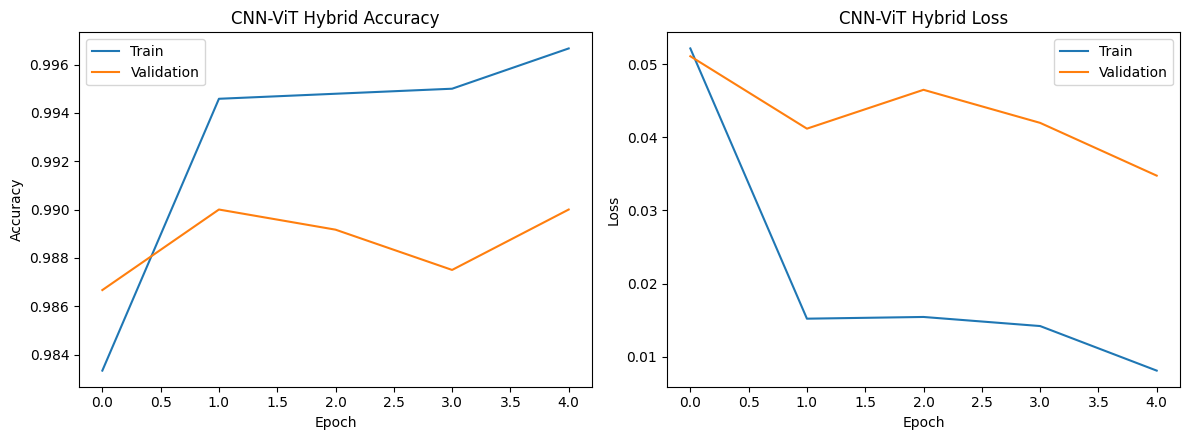

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN-ViT Hybrid Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("CNN-ViT Hybrid Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluation

In [13]:
y_true, y_pred_proba = [], []
for x_batch, y_batch in val_ds_ready:
    preds = hybrid_model.predict(x_batch, verbose=0).ravel()
    y_pred_proba.extend(preds)
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true)
y_pred = (np.array(y_pred_proba) >= 0.5).astype(int)

print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred):.4f}")


Accuracy : 0.9900
Precision: 0.9888
Recall   : 0.9920
F1-score : 0.9904


## 8. Save the trained hybrid model (needed for the final integration lab)

In [14]:
hybrid_model.save("keras_cnn_vit_hybrid.keras")
hybrid_model.save_weights("keras_cnn_vit_hybrid.weights.h5")
print("Saved model to keras_cnn_vit_hybrid.keras")
print("Saved weights to keras_cnn_vit_hybrid.weights.h5 (used by the final integration lab "
      "for robust cross-process loading, rebuilding the identical architecture in code and "
      "calling load_weights() -- this avoids a known Keras 3 limitation with re-deserializing "
      "custom layers that wrap a nested sub-model).")


Saved model to keras_cnn_vit_hybrid.keras
Saved weights to keras_cnn_vit_hybrid.weights.h5 (used by the final integration lab for robust cross-process loading, rebuilding the identical architecture in code and calling load_weights() -- this avoids a known Keras 3 limitation with re-deserializing custom layers that wrap a nested sub-model).


## Summary

Starting from a pretrained CNN, we identified `feature_layer_name` (the
last spatial feature map before classification), extracted intermediate
feature maps, reshaped them as tokens, added positional embeddings, and
stacked Transformer encoder blocks on top via `build_cnn_vit_hybrid`,
producing `hybrid_model`. We compiled it, set an explicit training
configuration, trained it, and evaluated it -- combining the CNN's local
detail extraction with the Transformer's global self-attention context.
